In [92]:
import os
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import random_split

In [93]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Load the Dataset

In [94]:
image_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [95]:
dataset_path = "./dataset"
dataset = datasets.ImageFolder(dataset_path, transform=image_transform)
len(dataset)

6151

In [96]:
dataset.classes

['crack', 'dent', 'glass_shatter', 'lamp_broken', 'scratch', 'tire_flat']

In [97]:
num_classes = len(dataset.classes)
num_classes

6

In [98]:
train_size = int(0.75*len(dataset))
val_size = len(dataset) - train_size
train_size, val_size

(4613, 1538)

In [99]:
class_name = dataset.classes
class_name

['crack', 'dent', 'glass_shatter', 'lamp_broken', 'scratch', 'tire_flat']

### Splitting the data into train and test dataset

In [100]:
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

### Loading the data using data loader

In [101]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [102]:
for images, labels in train_loader:
    print(images.shape, labels.shape)
    break

torch.Size([32, 3, 224, 224]) torch.Size([32])


### 32 is batch size 3 is color chanel i.e rgb 256, 256 is width and length

In [103]:
images[0].shape

torch.Size([3, 224, 224])

In [104]:
labels[0]

tensor(4)

In [105]:
images[0].permute(1,2,0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2739873].


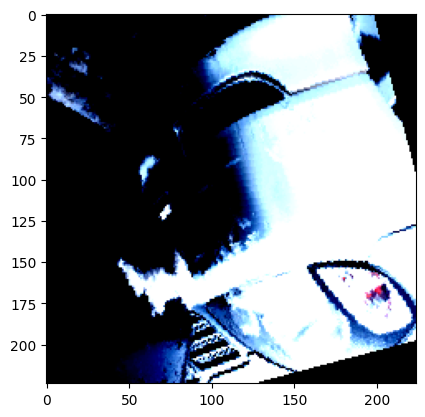

In [106]:
plt.imshow(images[1].permute(1,2,0))
plt.show()

### Train the Model using CNN

In [107]:
class CarClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1), # in: (3,224,224) out: (16,224,224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),  # out: (16, 112, 112)
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), # in: (16,112,112) out: (32,112,112)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),  # out: (32, 56, 56)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1), # in: (32,56,56) out: (64,56,56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),  # out: (64, 28, 28)
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes),
        )
    def forward(self, x):
        x = self.network(x)
        return x

In [108]:
model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [109]:
images.size(0), len(train_loader.dataset)

(32, 4613)

In [110]:
def train_model(model, criterion, optimizer, epochs=5):
    start = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        # Mini batch
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            if (batch_num + 1) % 10 == 0:
                print(f"Batch: {batch_num + 1}, Epoch: {epoch+1} ,Loss: {loss.item():.2f}")
            running_loss += loss.item() * images.size(0)
        epoch_loss = running_loss/len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")

        # Validation
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
            print(f"*** Validation Accuracy: {100 * correct / total:.2f}% ***")
    end = time.time()
    print(f"Execution Time: {end-start} seconds")
    return all_labels, all_predictions

In [111]:
values, indeices = torch.max(torch.tensor([[10,12,15,9,2]]), 1)
values, indeices

(tensor([15]), tensor([2]))

In [112]:
all_labels, all_predictions = train_model(model, criterion, optimizer, epochs=6)

Batch: 10, Epoch: 1 ,Loss: 1.83
Batch: 20, Epoch: 1 ,Loss: 1.68
Batch: 30, Epoch: 1 ,Loss: 1.66
Batch: 40, Epoch: 1 ,Loss: 1.69
Batch: 50, Epoch: 1 ,Loss: 1.63
Batch: 60, Epoch: 1 ,Loss: 1.66
Batch: 70, Epoch: 1 ,Loss: 1.53
Batch: 80, Epoch: 1 ,Loss: 1.52
Batch: 90, Epoch: 1 ,Loss: 1.59
Batch: 100, Epoch: 1 ,Loss: 1.56
Batch: 110, Epoch: 1 ,Loss: 1.49
Batch: 120, Epoch: 1 ,Loss: 1.63
Batch: 130, Epoch: 1 ,Loss: 1.39
Batch: 140, Epoch: 1 ,Loss: 1.51
Epoch [1/6], Avg Loss: 1.6917
*** Validation Accuracy: 32.18% ***
Batch: 10, Epoch: 2 ,Loss: 1.51
Batch: 20, Epoch: 2 ,Loss: 1.22
Batch: 30, Epoch: 2 ,Loss: 1.45
Batch: 40, Epoch: 2 ,Loss: 1.67
Batch: 50, Epoch: 2 ,Loss: 1.54
Batch: 60, Epoch: 2 ,Loss: 1.52
Batch: 70, Epoch: 2 ,Loss: 1.15
Batch: 80, Epoch: 2 ,Loss: 1.52
Batch: 90, Epoch: 2 ,Loss: 1.53
Batch: 100, Epoch: 2 ,Loss: 1.19
Batch: 110, Epoch: 2 ,Loss: 1.31
Batch: 120, Epoch: 2 ,Loss: 1.42
Batch: 130, Epoch: 2 ,Loss: 1.66
Batch: 140, Epoch: 2 ,Loss: 1.59
Epoch [2/6], Avg Loss: 1.467

# CNN with Regularization

In [113]:
class CarClassifierCNNWithregularization(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1), # in: (3,224,224) out: (16,224,224)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),  # out: (16, 112, 112)
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), # in: (16,112,112) out: (32,112,112)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),  # out: (32, 56, 56)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1), # in: (32,56,56) out: (64,56,56)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),  # out: (64, 28, 28)
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )
    def forward(self, x):
        x = self.network(x)
        return x

In [114]:
model = CarClassifierCNNWithregularization(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [115]:
all_labels, all_predictions = train_model(model, criterion, optimizer, epochs=5)

Batch: 10, Epoch: 1 ,Loss: 15.28
Batch: 20, Epoch: 1 ,Loss: 6.00
Batch: 30, Epoch: 1 ,Loss: 1.77
Batch: 40, Epoch: 1 ,Loss: 1.66
Batch: 50, Epoch: 1 ,Loss: 1.61
Batch: 60, Epoch: 1 ,Loss: 1.69
Batch: 70, Epoch: 1 ,Loss: 1.66
Batch: 80, Epoch: 1 ,Loss: 1.57
Batch: 90, Epoch: 1 ,Loss: 1.65
Batch: 100, Epoch: 1 ,Loss: 1.85
Batch: 110, Epoch: 1 ,Loss: 1.58
Batch: 120, Epoch: 1 ,Loss: 1.50
Batch: 130, Epoch: 1 ,Loss: 1.56
Batch: 140, Epoch: 1 ,Loss: 1.55
Epoch [1/5], Avg Loss: 4.0334
*** Validation Accuracy: 32.70% ***
Batch: 10, Epoch: 2 ,Loss: 1.60
Batch: 20, Epoch: 2 ,Loss: 1.65
Batch: 30, Epoch: 2 ,Loss: 1.51
Batch: 40, Epoch: 2 ,Loss: 1.63
Batch: 50, Epoch: 2 ,Loss: 1.62
Batch: 60, Epoch: 2 ,Loss: 1.67
Batch: 70, Epoch: 2 ,Loss: 1.75
Batch: 80, Epoch: 2 ,Loss: 1.63
Batch: 90, Epoch: 2 ,Loss: 1.67
Batch: 100, Epoch: 2 ,Loss: 1.70
Batch: 110, Epoch: 2 ,Loss: 1.54
Batch: 120, Epoch: 2 ,Loss: 1.71
Batch: 130, Epoch: 2 ,Loss: 1.78
Batch: 140, Epoch: 2 ,Loss: 1.61
Epoch [2/5], Avg Loss: 1.62

### Transfer Learning with EfficientNet

In [116]:
model = models.efficientnet_b0(weights='DEFAULT')
model.classifier[1].in_features

1280

In [117]:
class CarClassifierCNNWfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights='DEFAULT')
        # Freezing the other layers
        for param in self.model.parameters():
            param.requires_grad = False
        in_features = self.model.classifier[1].in_features
        # this is the last layer for classification
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes),
        )
    def forward(self,x):
        x = self.model(x)
        return x

In [118]:
model = CarClassifierCNNWfficientNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

In [119]:
train_model(model, criterion, optimizer, epochs=5)

Batch: 10, Epoch: 1 ,Loss: 1.65
Batch: 20, Epoch: 1 ,Loss: 1.51
Batch: 30, Epoch: 1 ,Loss: 1.53
Batch: 40, Epoch: 1 ,Loss: 1.31
Batch: 50, Epoch: 1 ,Loss: 1.42
Batch: 60, Epoch: 1 ,Loss: 1.25
Batch: 70, Epoch: 1 ,Loss: 1.38
Batch: 80, Epoch: 1 ,Loss: 1.43
Batch: 90, Epoch: 1 ,Loss: 1.51
Batch: 100, Epoch: 1 ,Loss: 1.29
Batch: 110, Epoch: 1 ,Loss: 1.28
Batch: 120, Epoch: 1 ,Loss: 1.31
Batch: 130, Epoch: 1 ,Loss: 1.15
Batch: 140, Epoch: 1 ,Loss: 1.30
Epoch [1/5], Avg Loss: 1.3983
*** Validation Accuracy: 48.50% ***
Batch: 10, Epoch: 2 ,Loss: 1.24
Batch: 20, Epoch: 2 ,Loss: 1.15
Batch: 30, Epoch: 2 ,Loss: 1.16
Batch: 40, Epoch: 2 ,Loss: 1.15
Batch: 50, Epoch: 2 ,Loss: 1.31
Batch: 60, Epoch: 2 ,Loss: 1.17
Batch: 70, Epoch: 2 ,Loss: 1.33
Batch: 80, Epoch: 2 ,Loss: 1.29
Batch: 90, Epoch: 2 ,Loss: 1.13
Batch: 100, Epoch: 2 ,Loss: 0.93
Batch: 110, Epoch: 2 ,Loss: 1.38
Batch: 120, Epoch: 2 ,Loss: 1.06
Batch: 130, Epoch: 2 ,Loss: 1.26
Batch: 140, Epoch: 2 ,Loss: 1.29
Epoch [2/5], Avg Loss: 1.231

([np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(4),
  np.int64(4),
  np.int64(4),
  np.int64(1),
  np.int64(4),
  np.int64(1),
  np.int64(1),
  np.int64(3),
  np.int64(0),
  np.int64(3),
  np.int64(4),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(5),
  np.int64(5),
  np.int64(2),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(4),
  np.int64(4),
  np.int64(4),
  np.int64(2),
  np.int64(2),
  np.int64(0),
  np.int64(2),
  np.int64(2),
  np.int64(3),
  np.int64(2),
  np.int64(3),
  np.int64(3),
  np.int64(0),
  np.int64(1),
  np.int64(4),
  np.int64(4),
  np.int64(1),
  np.int64(1),
  np.int64(3),
  np.int64(3),
  np.int64(1),
  np.int64(5),
  np.int64(1),
  np.int64(3),
  np.int64(1),
  np.int64(2),
  np.int64(1),
  np.int64(3),
  np.int64(3),
  np.int64(1),
  np.int64(5),
  np.int64(5),
  np.int64(4),
  np.int64(3),
  np.int64(1),
  np.int64(1),
  np.int64(4),
  np.int64(4),
  np.int64(4),
  np.int64

### Transfer Learning Using resNet

In [120]:
class CarClassifierCNNResNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        # Freezing all the layer except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
        # Unfreze layer4 and fc layesr
        for param in self.model.layer4.parameters():
            param.requires_grad = True
        # this is the last layer for fully connected layer i.e fc
        self.model.fc = nn.Sequential(
            nn.Dropout(0.3942947142510578),
            nn.Linear(self.model.fc.in_features, num_classes),
        )
    def forward(self,x):
        x = self.model(x)
        return x

In [121]:
model = CarClassifierCNNResNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.000871743346606561)
labels, predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1 ,Loss: 1.65
Batch: 20, Epoch: 1 ,Loss: 1.20
Batch: 30, Epoch: 1 ,Loss: 1.10
Batch: 40, Epoch: 1 ,Loss: 1.21
Batch: 50, Epoch: 1 ,Loss: 1.01
Batch: 60, Epoch: 1 ,Loss: 1.19
Batch: 70, Epoch: 1 ,Loss: 1.11
Batch: 80, Epoch: 1 ,Loss: 1.25
Batch: 90, Epoch: 1 ,Loss: 0.89
Batch: 100, Epoch: 1 ,Loss: 0.73
Batch: 110, Epoch: 1 ,Loss: 1.57
Batch: 120, Epoch: 1 ,Loss: 1.13
Batch: 130, Epoch: 1 ,Loss: 1.06
Batch: 140, Epoch: 1 ,Loss: 0.92
Epoch [1/10], Avg Loss: 1.1730
*** Validation Accuracy: 52.41% ***
Batch: 10, Epoch: 2 ,Loss: 1.09
Batch: 20, Epoch: 2 ,Loss: 0.84
Batch: 30, Epoch: 2 ,Loss: 0.92
Batch: 40, Epoch: 2 ,Loss: 1.07
Batch: 50, Epoch: 2 ,Loss: 1.21
Batch: 60, Epoch: 2 ,Loss: 1.17
Batch: 70, Epoch: 2 ,Loss: 0.91
Batch: 80, Epoch: 2 ,Loss: 1.35
Batch: 90, Epoch: 2 ,Loss: 0.94
Batch: 100, Epoch: 2 ,Loss: 0.90
Batch: 110, Epoch: 2 ,Loss: 0.78
Batch: 120, Epoch: 2 ,Loss: 1.06
Batch: 130, Epoch: 2 ,Loss: 1.12
Batch: 140, Epoch: 2 ,Loss: 1.17
Epoch [2/10], Avg Loss: 1.0

KeyboardInterrupt: 

## Model evaluation using confusion matrix and classification report

In [122]:
print(labels[:10])
print(predictions[:10])

tensor([4, 4, 4, 1, 2, 4, 4, 4, 4, 1])


NameError: name 'predictions' is not defined

In [123]:
from sklearn.metrics import classification_report
report = classification_report(labels, predictions)
print(report)

NameError: name 'predictions' is not defined

## Transfer Learning Using YOLOv8 (Classification)

### Why YOLOv8?
ResNet gave us ~50% accuracy. YOLOv8 (via `ultralytics`) is a modern, highly optimised backbone
that supports image **classification** out of the box with a simple API and faster convergence.

### Step 1 – Install ultralytics (if not already installed)

In [124]:
# Run only once – skip if ultralytics is already in the venv
import subprocess
subprocess.run(['pip', 'install', 'ultralytics', '-q'], check=True)
print('ultralytics installed successfully')

ultralytics installed successfully


### Step 2 – Prepare the Dataset Structure for YOLOv8
YOLOv8 classification expects:
```
yolo_dataset/
  train/ { crack/, dent/, glass_shatter/, lamp_broken/, scratch/, tire_flat/ }
  val/   { crack/, dent/, glass_shatter/, lamp_broken/, scratch/, tire_flat/ }
```
We build this from `./dataset` using the same 75/25 split used earlier.

In [125]:
import os
import shutil
import random

SOURCE_DIR  = './dataset'
TARGET_DIR  = './yolo_dataset'
TRAIN_RATIO = 0.75
SEED        = 42

random.seed(SEED)

# Remove previous build if it exists
if os.path.exists(TARGET_DIR):
    shutil.rmtree(TARGET_DIR)

for split in ('train', 'val'):
    for cls in os.listdir(SOURCE_DIR):
        os.makedirs(os.path.join(TARGET_DIR, split, cls), exist_ok=True)

for cls in os.listdir(SOURCE_DIR):
    cls_path = os.path.join(SOURCE_DIR, cls)
    if not os.path.isdir(cls_path):
        continue
    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    random.shuffle(images)
    split_idx = int(len(images) * TRAIN_RATIO)
    for fname in images[:split_idx]:
        shutil.copy(
            os.path.join(cls_path, fname),
            os.path.join(TARGET_DIR, 'train', cls, fname)
        )
    for fname in images[split_idx:]:
        shutil.copy(
            os.path.join(cls_path, fname),
            os.path.join(TARGET_DIR, 'val', cls, fname)
        )

# Sanity check
for split in ('train', 'val'):
    total = sum(
        len(os.listdir(os.path.join(TARGET_DIR, split, c)))
        for c in os.listdir(os.path.join(TARGET_DIR, split))
    )
    print(f'{split}: {total} images')

train: 4610 images
val: 1541 images


### Step 3 – Load the YOLOv8 Classification Model
`yolov8n-cls.pt` is the **nano** (fastest) variant pretrained on ImageNet.
For higher accuracy try `yolov8s-cls.pt` or `yolov8m-cls.pt`.

In [126]:
from ultralytics import YOLO

# Load pretrained YOLOv8 nano classification model
yolo_model = YOLO('yolov8n-cls.pt')
print('Model loaded:', type(yolo_model))

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Shyam\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded: <class 'ultralytics.models.yolo.model.YOLO'>


### Step 4 – Train the YOLOv8 Model

In [127]:
results = yolo_model.train(
    data     = TARGET_DIR,   # path to yolo_dataset/
    epochs   = 10,
    imgsz    = 224,           # same image size used in rest of notebook
    batch    = 32,
    device   = 0 if torch.cuda.is_available() else 'cpu',
    project  = 'yolo_runs',
    name     = 'car_damage_cls',
    exist_ok = True,
    verbose  = True
)
print('Training complete!')
print('Best model saved at:', results.save_dir)

Ultralytics 8.4.33  Python-3.13.1 torch-2.11.0+cpu CPU (AMD Ryzen 7 7435HS)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_dataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=car_damage_cls, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots

### Step 5 – Evaluate on the Validation Set

In [129]:
import os
import torch
import numpy as np

# Use the in-memory trained model if available, otherwise load from disk
try:
    _eval_model = yolo_model   # already trained in Step 4
    print('Using in-memory trained model.')
except NameError:
    from ultralytics import YOLO
    # Try to find best.pt from results, then fall back to a fixed path
    try:
        best_weights = os.path.join(str(results.save_dir), 'weights', 'best.pt')
    except NameError:
        best_weights = os.path.join('yolo_runs', 'car_damage_cls', 'weights', 'best.pt')
    _eval_model = YOLO(best_weights)
    print('Loaded model from:', best_weights)

# Class names in sorted order (same as ImageFolder)
val_dir    = os.path.join(TARGET_DIR, 'val')
cls_names  = sorted(os.listdir(val_dir))
cls_to_idx = {c: i for i, c in enumerate(cls_names)}

yolo_all_labels      = []
yolo_all_predictions = []

for cls in cls_names:
    cls_val_path = os.path.join(val_dir, cls)
    for fname in os.listdir(cls_val_path):
        fpath = os.path.join(cls_val_path, fname)
        try:
            pred = _eval_model.predict(fpath, verbose=False)[0]
            yolo_all_labels.append(cls_to_idx[cls])
            yolo_all_predictions.append(int(pred.probs.top1))
        except Exception as e:
            print(f'[SKIPPED] {fpath}: {e}')

accuracy = np.mean(np.array(yolo_all_labels) == np.array(yolo_all_predictions))
print(f'\n*** YOLOv8 Validation Accuracy: {accuracy * 100:.2f}% ***\n')

Using in-memory trained model.

*** YOLOv8 Validation Accuracy: 52.11% ***



### Step 6 – Classification Report

In [130]:
from sklearn.metrics import classification_report

report = classification_report(yolo_all_labels, yolo_all_predictions, target_names=cls_names)
print(report)

               precision    recall  f1-score   support

        crack       0.30      0.02      0.04       151
         dent       0.50      0.25      0.33       438
glass_shatter       0.86      0.83      0.85       169
  lamp_broken       0.35      0.36      0.36       174
      scratch       0.47      0.79      0.59       531
    tire_flat       0.80      0.86      0.83        78

     accuracy                           0.52      1541
    macro avg       0.55      0.52      0.50      1541
 weighted avg       0.51      0.52      0.48      1541



### Step 7 – Confusion Matrix

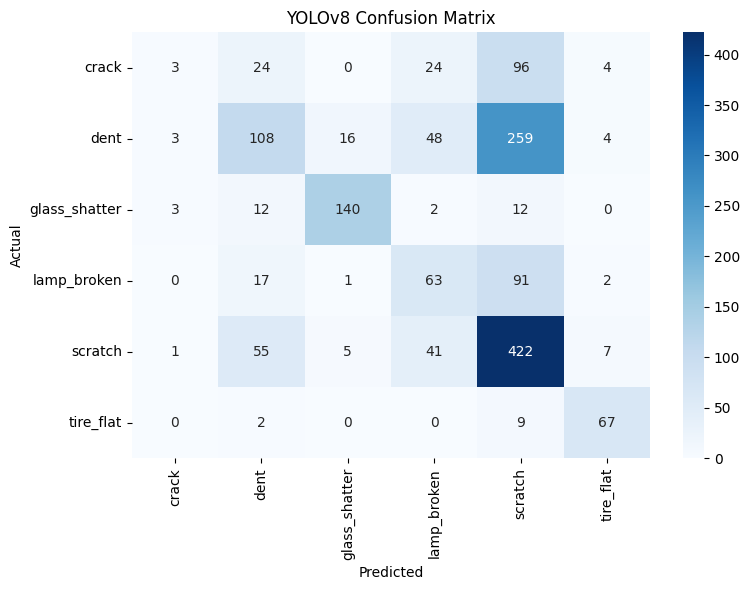

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yolo_all_labels, yolo_all_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=cls_names, yticklabels=cls_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('YOLOv8 Confusion Matrix')
plt.tight_layout()
plt.show()

### Step 8 – Export / Save the Final Model
Export to **ONNX** for inference in production, or keep `.pt` weights for Torch-based serving.

In [133]:
# Export to ONNX (optional – comment out if not needed)
# _eval_model was set in the evaluation cell above
_eval_model.export(format='onnx', imgsz=224)
print('Model exported to ONNX format.')

# Show where the best PyTorch weights are saved
import os
try:
    _best_pt = os.path.join(str(results.save_dir), 'weights', 'best.pt')
except NameError:
    _best_pt = os.path.join('yolo_runs', 'car_damage_cls', 'weights', 'best.pt')
print('PyTorch best weights:', _best_pt)

Ultralytics 8.4.33  Python-3.13.1 torch-2.11.0+cpu CPU (AMD Ryzen 7 7435HS)

PyTorch: starting from 'C:\Users\Shyam\PycharmProjects\MiniProject\Backend\runs\classify\yolo_runs\car_damage_cls\weights\best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 6) (2.8 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Resolved 12 packages in 742ms
 Downloaded onnxruntime
 Downloaded onnx
Prepared 5 packages in 11.76s
Installed 5 packages in 8.68s
 + flatbuffers==25.12.19
 + ml-dtypes==0.5.4
 + onnx==1.21.0
 + onnxruntime==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success  25.5s
WARNING requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success  28.1s, saved as 'C:\Users\Shyam\PycharmProjects\MiniProject\Backend\runs\classify\yolo_runs\car_damage_cls\weig